# Cost-Weighted GEC DELCODE Whole-Brain Classifier with 5-Fold Stratified Cross-Validation

In [1]:
import sys
from pathlib import Path

model_root = Path('/mnt/e/fyassine/ad-early-detection/MODEL')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(model_root))

print(f'Added to sys.path: {model_root}')

Added to sys.path: /mnt/e/fyassine/ad-early-detection/MODEL


In [2]:
import json
import numpy as np
import os
import torch
import wandb
import pandas as pd
import seaborn as sns

from pathlib import Path
from matplotlib import pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from torch_geometric.loader import DataLoader
from copy import deepcopy
from datetime import datetime

from model.CostWeightedGEC.dataset import ClassificationDataset, CombinedClassificationDataset
from model.CostWeightedGEC.models import GraphEncoderClassifierAttention
from model.CostWeightedGEC.utils import (
    load_frozen_encoder_from_gaae,
    compute_class_weights,
    compute_class_cost_weights,
    knn_binary_adjacency_matrix_no_diag,
)
from model.CostWeightedGEC.train import train_classifier

sns.set_theme(style='whitegrid')

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration

In [4]:
try:
    wandb.login()
except Exception:
    pass

WANDB_PROJECT = 'cost-weighted-gec-converter-classification-whole-brain'

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/wunderlich/.netrc.
wandb: Currently logged in as: lakhalfrajyassine (lakhalfrajyassine-technical-university-of-munich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
WB_ROOT = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v3__/matrices'
METADATA_DIR = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v4__/metadata'
COHORTS_CSV = os.path.join(METADATA_DIR, 'cohorts.csv')
GEC_SPLITS_DIR = os.path.join(METADATA_DIR, 'splits_gec')
TRAIN_SPLIT_CSV = os.path.join(GEC_SPLITS_DIR, 'train.csv')
VAL_SPLIT_CSV = os.path.join(GEC_SPLITS_DIR, 'val.csv')

CHECKPOINT_SEARCH_DIRS = [
    str(model_root / 'notebooks' / 'checkpoints_gaae_whole_brain'),
]

CW_GEC_OUTPUT_DIR = str(model_root / 'notebooks' / 'checkpoints_cost_weighted_gec_whole_brain')
os.makedirs(CW_GEC_OUTPUT_DIR, exist_ok=True)
CW_GEC_CHECKPOINT_SEARCH_DIRS = [CW_GEC_OUTPUT_DIR]
USE_CW_GEC_CHECKPOINT = False

IN_FEATURES = 400
HIDDEN_DIM = 400
LATENT_DIM = 32
COND_DIM = 2
NUM_HEADS = 2
DROPOUT = 0.5
CLASSIFIER_HIDDEN = 32

BATCH_SIZE = 16
LEARNING_RATE = 0.001
EPOCHS = 25
EARLY_STOPPING_PATIENCE = 30
USE_SCHEDULER = True

USE_CLASS_COST_WEIGHTS = True
NORMALIZE_CLASS_COST_WEIGHTS = True

KNN_K = 8
adjacency_args = {'k': KNN_K}
CORRELATION_TYPE = 'whole_brain'
FILE_VARIANT = 'z_transformed'

FREEZE_ENCODER = False
CLASSIFICATION_THRESHOLD = 0.35

N_FOLDS = 5
RANDOM_STATE = 42

In [6]:
checkpoint_candidates = sorted(
    [
        (run_dir.name, str(model_file), str(run_dir))
        for checkpoint_dir in CHECKPOINT_SEARCH_DIRS
        for base_dir in [Path(checkpoint_dir)]
        if base_dir.is_dir()
        for run_dir in sorted(base_dir.iterdir())
        if run_dir.is_dir()
        for model_file in [run_dir / f'model_{run_dir.name}.pth']
        if model_file.exists()
    ],
    key=lambda x: x[0],
)

if not checkpoint_candidates:
    raise FileNotFoundError('No GAAE checkpoints found. Train MODEL/notebooks/GAAE_DELCODE_WHOLE_BRAIN.ipynb first.')

print('Available GAAE checkpoints:')
for i, (run_name, _, run_dir) in enumerate(checkpoint_candidates):
    print(f'  {i}: {run_name} ({run_dir})')

default_index = len(checkpoint_candidates) - 1
selected_run_index_text = input(f'Select a GAAE checkpoint by index [default {default_index}]: ').strip()
selected_run_index = default_index if selected_run_index_text == '' else int(selected_run_index_text)
if selected_run_index < 0 or selected_run_index >= len(checkpoint_candidates):
    raise IndexError(f'GAAE checkpoint index out of range: {selected_run_index}')

RUN_NAME, GAAE_CHECKPOINT_PATH, SELECTED_RUN_DIR = checkpoint_candidates[selected_run_index]

run_config_path = Path(SELECTED_RUN_DIR) / 'run_config.json'
if run_config_path.exists():
    with open(run_config_path, 'r') as f:
        run_config = json.load(f)
    model_cfg = run_config.get('model_config', {})
    IN_FEATURES = int(model_cfg.get('in_features', IN_FEATURES))
    HIDDEN_DIM = int(model_cfg.get('hidden_size', HIDDEN_DIM))
    LATENT_DIM = int(model_cfg.get('latent_dim', LATENT_DIM))
    NUM_HEADS = int(model_cfg.get('attention_heads', NUM_HEADS))
    DROPOUT = float(model_cfg.get('dropout', DROPOUT))
    print(f'Loaded run config from {run_config_path}')

print(f'Using GAAE checkpoint: {GAAE_CHECKPOINT_PATH}')
print(f'Configured dims: in={IN_FEATURES}, latent={LATENT_DIM}, heads={NUM_HEADS}, dropout={DROPOUT}')

mode_input = input('Select Cost-Weighted GEC mode: [1] use existing checkpoint, [2] train (default: 2): ').strip().lower()
if mode_input in {'', '2', 't', 'train'}:
    USE_CW_GEC_CHECKPOINT = False
elif mode_input in {'1', 'c', 'checkpoint'}:
    USE_CW_GEC_CHECKPOINT = True
else:
    raise ValueError('Invalid mode selection. Use 1/checkpoint or 2/train.')

print(f"Cost-Weighted GEC mode selected: {'checkpoint' if USE_CW_GEC_CHECKPOINT else 'train'}")

if USE_CW_GEC_CHECKPOINT:
    cw_checkpoint_candidates = sorted(
        [
            (run_dir.name, str(model_file), str(run_dir))
            for checkpoint_dir in CW_GEC_CHECKPOINT_SEARCH_DIRS
            for base_dir in [Path(checkpoint_dir)]
            if base_dir.is_dir()
            for run_dir in sorted(base_dir.iterdir())
            if run_dir.is_dir()
            for model_file in sorted(run_dir.glob('best_model_fold*.pth'))
        ],
        key=lambda x: x[0],
    )

    if not cw_checkpoint_candidates:
        raise FileNotFoundError('No Cost-Weighted GEC checkpoints found. Switch to training mode to create one.')

    print('Available Cost-Weighted GEC checkpoints:')
    for i, (run_name, model_file, run_dir) in enumerate(cw_checkpoint_candidates):
        print(f'  {i}: {run_name} ({model_file})')

    default_cw_index = len(cw_checkpoint_candidates) - 1
    selected_cw_index_text = input(f'Select a Cost-Weighted GEC checkpoint by index [default {default_cw_index}]: ').strip()
    selected_cw_index = default_cw_index if selected_cw_index_text == '' else int(selected_cw_index_text)
    if selected_cw_index < 0 or selected_cw_index >= len(cw_checkpoint_candidates):
        raise IndexError(f'Cost-Weighted GEC checkpoint index out of range: {selected_cw_index}')

    CW_GEC_RUN_NAME, CW_GEC_CHECKPOINT_PATH, CW_GEC_SELECTED_RUN_DIR = cw_checkpoint_candidates[selected_cw_index]
    run_artifact_dir = CW_GEC_SELECTED_RUN_DIR
    active_run_dir = Path(run_artifact_dir)
    print(f'Using Cost-Weighted GEC checkpoint: {CW_GEC_CHECKPOINT_PATH}')
    print(f'Using checkpoint artifact directory: {active_run_dir}')
else:
    CW_GEC_RUN_NAME = None
    CW_GEC_CHECKPOINT_PATH = None
    CW_GEC_SELECTED_RUN_DIR = None

Available GAAE checkpoints:
  0: worldly-plasma-2_2026-03-24_01-00-18 (/mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18)
Loaded run config from /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18/run_config.json
Using GAAE checkpoint: /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18/model_worldly-plasma-2_2026-03-24_01-00-18.pth
Configured dims: in=200, latent=64, heads=2, dropout=0.3
Cost-Weighted GEC mode selected: train


In [7]:
if not os.path.exists(GAAE_CHECKPOINT_PATH):
    raise FileNotFoundError(f'Checkpoint not found: {GAAE_CHECKPOINT_PATH}')
print(f'Checkpoint ready: {GAAE_CHECKPOINT_PATH}')

Checkpoint ready: /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18/model_worldly-plasma-2_2026-03-24_01-00-18.pth


## Load Datasets

In [8]:
split_paths = {
    'train': TRAIN_SPLIT_CSV,
    'val': VAL_SPLIT_CSV,
}
allowed_diagnoses = {'converter', 'mci'}

cohorts_df = pd.read_csv(COHORTS_CSV)
id_candidates = ['Repseudonym', 'Pseudonym', 'ID']
cohort_id_col = next((c for c in id_candidates if c in cohorts_df.columns), None)
if cohort_id_col is None:
    raise ValueError(
        f"Missing subject ID column in cohorts CSV. Expected one of {id_candidates}, found: {list(cohorts_df.columns)}"
    )
if 'diagnosis' not in cohorts_df.columns:
    raise ValueError(f"Missing 'diagnosis' column in cohorts CSV: {COHORTS_CSV}")

cohorts_df[cohort_id_col] = cohorts_df[cohort_id_col].astype(str)
cohorts_df['diagnosis'] = cohorts_df['diagnosis'].astype(str).str.lower().str.strip()
cohort_diag_map = cohorts_df.groupby(cohort_id_col)['diagnosis'].apply(lambda s: set(s)).to_dict()

split_frames = {}
base_required_cols = {'Repseudonym', 'sex', 'age', 'diagnosis'}
for name, path in split_paths.items():
    df = pd.read_csv(path)
    missing_base = base_required_cols - set(df.columns)
    assert not missing_base, f'Split {name}.csv missing columns: {missing_base}'

    df = df.copy()
    df['Repseudonym'] = df['Repseudonym'].astype(str)
    df['diagnosis'] = df['diagnosis'].astype(str).str.lower().str.strip()

    invalid_labels = sorted(set(df['diagnosis']) - allowed_diagnoses)
    if invalid_labels:
        raise ValueError(
            f"Split {name}.csv contains diagnoses outside {sorted(allowed_diagnoses)}: {invalid_labels}"
        )

    missing_in_cohorts = sorted(set(df['Repseudonym']) - set(cohort_diag_map.keys()))
    if missing_in_cohorts:
        raise ValueError(
            f"Split {name}.csv has IDs missing in cohorts.csv (first 10): {missing_in_cohorts[:10]}"
        )

    mismatched = [
        sid for sid, diag in zip(df['Repseudonym'], df['diagnosis'])
        if diag not in cohort_diag_map.get(sid, set())
    ]
    if mismatched:
        raise ValueError(
            f"Split {name}.csv has diagnosis not matched in cohorts.csv (first 10 IDs): {mismatched[:10]}"
        )

    df['converter_status'] = (df['diagnosis'] == 'converter').astype(int)
    split_frames[name] = df

for name, df in split_frames.items():
    counts = df['diagnosis'].value_counts().to_dict()
    n_subjects = int(df['Repseudonym'].nunique())
    if 'n_scans' in df.columns:
        total_scans_from_metadata = int(pd.to_numeric(df['n_scans'], errors='coerce').fillna(0).sum())
        print(
            f"{name}: subjects={n_subjects}, total_scans(metadata n_scans)={total_scans_from_metadata}, diagnosis_counts={counts}"
        )
    else:
        print(f"{name}: subjects={n_subjects}, diagnosis_counts={counts}")

all_splits_df = pd.concat(split_frames.values(), ignore_index=True)
all_splits_df = all_splits_df.drop_duplicates(subset=['Repseudonym'], keep='first')
all_splits_df['Repseudonym'] = all_splits_df['Repseudonym'].astype(str)

patient_info_df = all_splits_df[['Repseudonym', 'sex', 'age']].rename(columns={'Repseudonym': 'Pseudonym'}).set_index('Pseudonym')
converter_ids = sorted(all_splits_df.loc[all_splits_df['diagnosis'] == 'converter', 'Repseudonym'].unique())
non_converter_ids = sorted(all_splits_df.loc[all_splits_df['diagnosis'] == 'mci', 'Repseudonym'].unique())

import tempfile
patient_info_path = tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False).name
patient_info_df.to_csv(patient_info_path)

converter_dataset = ClassificationDataset(
    root=WB_ROOT,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    patient_info_path=patient_info_path,
    is_converter_dataset=True,
    separator=',',
    correlation_type=CORRELATION_TYPE,
    subject_ids=converter_ids,
    file_variant=FILE_VARIANT,
    filter_csv_path=None,
    converter_list_path=None,
)

non_converter_dataset = ClassificationDataset(
    root=WB_ROOT,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    patient_info_path=patient_info_path,
    is_converter_dataset=False,
    separator=',',
    correlation_type=CORRELATION_TYPE,
    subject_ids=non_converter_ids,
    file_variant=FILE_VARIANT,
    filter_csv_path=None,
    converter_list_path=None,
)

print(f'Converter dataset size: scans={len(converter_dataset)}, subjects={len(converter_ids)}')
print(f'Non-converter dataset size: scans={len(non_converter_dataset)}, subjects={len(non_converter_ids)}')

train: subjects=86, total_scans(metadata n_scans)=177, diagnosis_counts={'converter': 43, 'mci': 43}
val: subjects=16, total_scans(metadata n_scans)=46, diagnosis_counts={'converter': 8, 'mci': 8}
Converter dataset size: scans=196, subjects=51
Non-converter dataset size: scans=402, subjects=51


In [9]:
combined_dataset = CombinedClassificationDataset(converter_dataset, non_converter_dataset)
all_labels = combined_dataset.get_labels()

total_scans = int(len(combined_dataset))
total_subjects = int(len(set(converter_ids).union(set(non_converter_ids))))
converter_scans = int(sum(all_labels))
non_converter_scans = int(total_scans - converter_scans)
converter_subjects = int(len(converter_ids))
non_converter_subjects = int(len(non_converter_ids))

print('\nCombined dataset:')
print(f'  Total scans: {total_scans}')
print(f'  Total subjects: {total_subjects}')
print(f'  Converter scans: {converter_scans} ({(converter_scans / total_scans * 100) if total_scans else 0:.1f}%)')
print(f'  Non-converter scans: {non_converter_scans} ({(non_converter_scans / total_scans * 100) if total_scans else 0:.1f}%)')
print(f'  Converter subjects: {converter_subjects} ({(converter_subjects / total_subjects * 100) if total_subjects else 0:.1f}%)')
print(f'  Non-converter subjects: {non_converter_subjects} ({(non_converter_subjects / total_subjects * 100) if total_subjects else 0:.1f}%)')


Combined dataset:
  Total scans: 598
  Total subjects: 102
  Converter scans: 196 (32.8%)
  Non-converter scans: 402 (67.2%)
  Converter subjects: 51 (50.0%)
  Non-converter subjects: 51 (50.0%)


## Load Splits from Whole-Brain Metadata CSVs

Train + validation IDs form the cross-validation pool.

In [10]:
train_ids = set(split_frames['train']['Repseudonym'].astype(str))
val_ids = set(split_frames['val']['Repseudonym'].astype(str))

patient_to_indices = {}
index_to_patient = {}
for idx in range(len(combined_dataset)):
    patient_id = str(getattr(combined_dataset[idx], 'patient_id', ''))
    index_to_patient[idx] = patient_id
    patient_to_indices.setdefault(patient_id, []).append(idx)

def get_split_indices(patient_ids):
    indices = []
    for pid in patient_ids:
        indices.extend(patient_to_indices.get(str(pid), []))
    return sorted(indices)

train_split_indices = get_split_indices(train_ids)
val_split_indices = get_split_indices(val_ids)

cv_indices = train_split_indices + val_split_indices
cv_labels = [all_labels[i] for i in cv_indices]

train_subjects_with_scans = {index_to_patient[i] for i in train_split_indices if index_to_patient[i] != ''}
val_subjects_with_scans = {index_to_patient[i] for i in val_split_indices if index_to_patient[i] != ''}

train_converter_subjects = int(split_frames['train']['converter_status'].sum())
val_converter_subjects = int(split_frames['val']['converter_status'].sum())

cv_pos = int(sum(cv_labels))
cv_subject_ids = set(train_ids).union(set(val_ids))
cv_converter_subjects = int(train_converter_subjects + val_converter_subjects)

cv_scan_rate = (cv_pos / len(cv_labels) * 100) if cv_labels else 0.0
cv_subject_rate = (cv_converter_subjects / len(cv_subject_ids) * 100) if cv_subject_ids else 0.0

print('Whole-brain split sizes (subjects vs scans):')
print(
    f'  Train split: listed_subjects={len(train_ids)}, subjects_with_scans={len(train_subjects_with_scans)}, '
    f'scans={len(train_split_indices)}, converter_subjects={train_converter_subjects}'
)
print(
    f'  Validation split: listed_subjects={len(val_ids)}, subjects_with_scans={len(val_subjects_with_scans)}, '
    f'scans={len(val_split_indices)}, converter_subjects={val_converter_subjects}'
)

print(
    f'\nCV set: scans={len(cv_indices)}, subjects={len(cv_subject_ids)}, '
    f'converter_scans={cv_pos} ({cv_scan_rate:.1f}%), '
    f'converter_subjects={cv_converter_subjects} ({cv_subject_rate:.1f}%)'
)

Whole-brain split sizes (subjects vs scans):
  Train split: listed_subjects=86, subjects_with_scans=86, scans=177, converter_subjects=43
  Validation split: listed_subjects=16, subjects_with_scans=16, scans=46, converter_subjects=8

CV set: scans=223, subjects=102, converter_scans=172 (77.1%), converter_subjects=51 (50.0%)


## 5-Fold Stratified Cross-Validation

In [11]:
cv_results = {
    'fold': [],
    'val_auc': [],
    'val_sensitivity': [],
    'val_specificity': [],
    'val_f1': [],
    'best_threshold': [],
    'best_epoch': [],
    'pos_weight': [],
    'class_cost_weights': [],
}

cv_histories = {
    'train_loss': [],
    'val_loss': [],
}

best_model_state = None
best_val_auc = 0.0
best_fold = -1
best_threshold_overall = float(CLASSIFICATION_THRESHOLD)

if USE_CW_GEC_CHECKPOINT:
    if CW_GEC_CHECKPOINT_PATH is None:
        raise RuntimeError('Cost-Weighted GEC checkpoint mode is enabled but no checkpoint path was selected.')

    checkpoint_obj = torch.load(CW_GEC_CHECKPOINT_PATH, map_location=device)

    model = GraphEncoderClassifierAttention(
        in_features=IN_FEATURES,
        hidden_dim=HIDDEN_DIM,
        latent_dim=LATENT_DIM,
        cond_dim=COND_DIM,
        num_heads=NUM_HEADS,
        dropout=DROPOUT,
        classifier_hidden=CLASSIFIER_HIDDEN,
    ).to(device)

    model = load_frozen_encoder_from_gaae(model, GAAE_CHECKPOINT_PATH, device=device)
    if not FREEZE_ENCODER:
        model.unfreeze_encoder()

    if isinstance(checkpoint_obj, torch.nn.Module):
        model = checkpoint_obj.to(device)
        best_model_state = model.state_dict()
    elif isinstance(checkpoint_obj, dict):
        if 'state_dict' in checkpoint_obj and isinstance(checkpoint_obj['state_dict'], dict):
            state_dict = checkpoint_obj['state_dict']
        elif 'model_state_dict' in checkpoint_obj and isinstance(checkpoint_obj['model_state_dict'], dict):
            state_dict = checkpoint_obj['model_state_dict']
        else:
            state_dict = checkpoint_obj
        model.load_state_dict(state_dict)
        best_model_state = state_dict
    else:
        raise TypeError('Unsupported Cost-Weighted GEC checkpoint format. Expected torch.nn.Module or state_dict.')

    model.eval()
    best_model = model

    run_summary_path = Path(CW_GEC_SELECTED_RUN_DIR) / 'run_summary.json'
    cv_results_path = Path(CW_GEC_SELECTED_RUN_DIR) / 'cv_results.json'

    if run_summary_path.exists():
        with open(run_summary_path, 'r') as f:
            run_summary = json.load(f)

        loaded_cv_results = run_summary.get('cv_results', {})
        if isinstance(loaded_cv_results, dict):
            for key in cv_results.keys():
                values = loaded_cv_results.get(key)
                if isinstance(values, list):
                    cv_results[key] = values

        loaded_cv_histories = run_summary.get('cv_histories', {})
        if isinstance(loaded_cv_histories, dict):
            train_histories = loaded_cv_histories.get('train_loss', [])
            val_histories = loaded_cv_histories.get('val_loss', [])
            if isinstance(train_histories, list):
                cv_histories['train_loss'] = train_histories
            if isinstance(val_histories, list):
                cv_histories['val_loss'] = val_histories

        best_fold = int(run_summary.get('best_fold', best_fold))
        best_val_auc = float(run_summary.get('best_val_auc', best_val_auc))
        best_threshold_overall = float(run_summary.get('best_threshold', best_threshold_overall))
    elif cv_results_path.exists():
        with open(cv_results_path, 'r') as f:
            loaded_cv_results = json.load(f)
        if isinstance(loaded_cv_results, dict):
            for key in cv_results.keys():
                values = loaded_cv_results.get(key)
                if isinstance(values, list):
                    cv_results[key] = values

        if len(cv_results['val_auc']) > 0:
            val_auc_arr = np.array(cv_results['val_auc'], dtype=float)
            best_idx = int(np.argmax(val_auc_arr))
            best_val_auc = float(val_auc_arr[best_idx])
            if len(cv_results['fold']) > best_idx:
                best_fold = int(cv_results['fold'][best_idx])

        if len(cv_results['best_threshold']) > 0:
            best_threshold_overall = float(np.mean(np.array(cv_results['best_threshold'], dtype=float)))

    print(f'Loaded Cost-Weighted GEC checkpoint from {CW_GEC_CHECKPOINT_PATH}')
    print('Cross-validation skipped because checkpoint mode is enabled')
else:
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    print(f'Starting {N_FOLDS}-fold stratified cross-validation...')
    print('========================')

    for fold, (train_idx_in_cv, val_idx_in_cv) in enumerate(skf.split(cv_indices, cv_labels)):
        print('========================')
        print(f'FOLD {fold + 1}/{N_FOLDS}')
        print('========================')

        train_idx = [cv_indices[i] for i in train_idx_in_cv]
        val_idx = [cv_indices[i] for i in val_idx_in_cv]

        train_labels_fold = [all_labels[i] for i in train_idx]
        val_labels_fold = [all_labels[i] for i in val_idx]

        train_subjects_fold = {str(getattr(combined_dataset[i], 'patient_id', '')) for i in train_idx}
        val_subjects_fold = {str(getattr(combined_dataset[i], 'patient_id', '')) for i in val_idx}
        train_subjects_fold.discard('')
        val_subjects_fold.discard('')

        train_converter_subjects_fold = {
            str(getattr(combined_dataset[i], 'patient_id', ''))
            for i in train_idx
            if int(all_labels[i]) == 1
        }
        val_converter_subjects_fold = {
            str(getattr(combined_dataset[i], 'patient_id', ''))
            for i in val_idx
            if int(all_labels[i]) == 1
        }
        train_converter_subjects_fold.discard('')
        val_converter_subjects_fold.discard('')

        train_converter_scans = int(sum(train_labels_fold))
        val_converter_scans = int(sum(val_labels_fold))
        train_converter_scan_rate = (train_converter_scans / len(train_labels_fold) * 100) if train_labels_fold else 0.0
        val_converter_scan_rate = (val_converter_scans / len(val_labels_fold) * 100) if val_labels_fold else 0.0

        print(
            f'Train: scans={len(train_idx)}, subjects={len(train_subjects_fold)}, '
            f'converter_scans={train_converter_scans} ({train_converter_scan_rate:.1f}%), '
            f'converter_subjects={len(train_converter_subjects_fold)}'
        )
        print(
            f'Val: scans={len(val_idx)}, subjects={len(val_subjects_fold)}, '
            f'converter_scans={val_converter_scans} ({val_converter_scan_rate:.1f}%), '
            f'converter_subjects={len(val_converter_subjects_fold)}'
        )

        train_dataset = torch.utils.data.Subset(combined_dataset, train_idx)
        val_dataset = torch.utils.data.Subset(combined_dataset, val_idx)

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

        pos_weight = compute_class_weights(train_labels_fold, device=device)
        if USE_CLASS_COST_WEIGHTS:
            class_cost_weights = compute_class_cost_weights(
                train_labels_fold,
                device=device,
                normalize=NORMALIZE_CLASS_COST_WEIGHTS,
            )
        else:
            class_cost_weights = None

        print(f'  pos_weight: {float(pos_weight):.6f}')
        print(f'  class_cost_weights: {class_cost_weights.tolist() if class_cost_weights is not None else None}')

        model = GraphEncoderClassifierAttention(
            in_features=IN_FEATURES,
            hidden_dim=HIDDEN_DIM,
            latent_dim=LATENT_DIM,
            cond_dim=COND_DIM,
            num_heads=NUM_HEADS,
            dropout=DROPOUT,
            classifier_hidden=CLASSIFIER_HIDDEN,
        ).to(device)

        model = load_frozen_encoder_from_gaae(model, GAAE_CHECKPOINT_PATH, device=device)

        if not FREEZE_ENCODER:
            model.unfreeze_encoder()

        optimizer = torch.optim.Adam(model.get_trainable_params(), lr=LEARNING_RATE)

        fold_model_state, history = train_classifier(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            device=device,
            pos_weight=pos_weight,
            class_cost_weights=class_cost_weights,
            epochs=EPOCHS,
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            model_save_path=None,
            project_name=WANDB_PROJECT,
            use_scheduler=USE_SCHEDULER,
        )

        model.load_state_dict(fold_model_state)
        model.eval()

        all_preds = []
        all_targets = []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                cond_vec = torch.stack([batch.patient_age, batch.patient_sex.float()], dim=1).to(device)
                output, _ = model(batch.x, batch.edge_index, cond_vec, batch.batch)
                probs = torch.sigmoid(output).cpu().numpy()
                all_preds.extend(probs.flatten())
                all_targets.extend(batch.is_converter.cpu().numpy().flatten())

        all_preds = np.array(all_preds)
        all_targets = np.array(all_targets)

        fpr, tpr, thresholds = roc_curve(all_targets, all_preds)
        fold_auc = auc(fpr, tpr)
        j_scores = tpr - fpr
        best_threshold_idx = np.argmax(j_scores)
        best_threshold = thresholds[best_threshold_idx]

        binary_preds = (all_preds >= best_threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(all_targets, binary_preds).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0

        cv_results['fold'].append(fold + 1)
        cv_results['val_auc'].append(fold_auc)
        cv_results['val_sensitivity'].append(sensitivity)
        cv_results['val_specificity'].append(specificity)
        cv_results['val_f1'].append(f1)
        cv_results['best_threshold'].append(float(best_threshold))
        cv_results['best_epoch'].append(len(history['train_loss']))
        cv_results['pos_weight'].append(float(pos_weight))
        cv_results['class_cost_weights'].append(class_cost_weights.detach().cpu().tolist() if class_cost_weights is not None else None)
        cv_histories['train_loss'].append(list(history.get('train_loss', [])))
        cv_histories['val_loss'].append(list(history.get('val_loss', [])))

        print(f'\nFold {fold+1} Results:')
        print(f'  AUC: {fold_auc:.4f}')
        print(f'  Sensitivity: {sensitivity:.4f}')
        print(f'  Specificity: {specificity:.4f}')
        print(f'  F1: {f1:.4f}')
        print(f'  Best Threshold: {best_threshold:.4f}')

        if fold_auc > best_val_auc:
            best_val_auc = fold_auc
            best_model_state = deepcopy(fold_model_state)
            best_fold = fold + 1
            best_threshold_overall = float(best_threshold)

        try:
            wandb.finish()
        except Exception:
            pass

    if best_model_state is not None:
        best_model = GraphEncoderClassifierAttention(
            in_features=IN_FEATURES,
            hidden_dim=HIDDEN_DIM,
            latent_dim=LATENT_DIM,
            cond_dim=COND_DIM,
            num_heads=NUM_HEADS,
            dropout=DROPOUT,
            classifier_hidden=CLASSIFIER_HIDDEN,
        ).to(device)
        best_model = load_frozen_encoder_from_gaae(best_model, GAAE_CHECKPOINT_PATH, device=device)
        if not FREEZE_ENCODER:
            best_model.unfreeze_encoder()
        best_model.load_state_dict(best_model_state)
        best_model.eval()

    print('========================')
    print('CROSS-VALIDATION COMPLETE')
    print('========================')

Starting 5-fold stratified cross-validation...
FOLD 1/5
Train: scans=178, subjects=90, converter_scans=137 (77.0%), converter_subjects=49
Val: scans=45, subjects=35, converter_scans=35 (77.8%), converter_subjects=25
  pos_weight: 0.299270
  class_cost_weights: [1.5393258333206177, 0.46067413687705994]
Loaded 36 pretrained encoder parameters from /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18/model_worldly-plasma-2_2026-03-24_01-00-18.pth


/mnt/e/fyassine/ad-early-detection/MODEL/model/CostWeightedGEC/models.py:128: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.attention_pool = GlobalAttention(gate_nn)


Training Progress:   0%|          | 0/25 [00:00<?, ?it/s]


Fold 1 Results:
  AUC: 0.6300
  Sensitivity: 0.6857
  Specificity: 0.7000
  F1: 0.7742
  Best Threshold: 0.9985


learning_rate,█████████████████▁▁▁▁▁▁▁▁
train_acc,▁▁▁▃▅▆▇▇█████████████████
train_auc,▁▂▃▆▇▇███████████████████
train_f1,▁▁▁▄▆▇███████████████████
train_loss,██▇▆▄▆▃▂▂▂▂▃▁▁▁▁▁▁▁▂▁▁▁▁▁
val_acc,▁▁▁▂▅▄▆▆▆▇▇▇▇█▇▆▇▇▇▇▇▇▇▇▇
val_auc,▁▃▂▃▃▅▅▆▅▆▇▆▆▆▅▅▆█▇▇███▇█
val_f1,▁▁▁▃▇▅▇▇▇▇██▇█▇▇███████▇█
val_loss,▁▁▁▁▂▂▂▄▄▄▅▇▆▇▆▇▆▇█▇▇▇██▇
learning_rate,0.0005
train_acc,1


...

Training Progress:   0%|          | 0/25 [00:00<?, ?it/s]


Fold 5 Results:
  AUC: 0.7853
  Sensitivity: 0.6176
  Specificity: 1.0000
  F1: 0.7636
  Best Threshold: 0.2961


learning_rate,████████████████▃▃▃▃▃▃▁▁▁
train_acc,▂▁▁▁▂▅▆▇▇▇███████████████
train_auc,▁▃▃▄▆▇█▇▇████████████████
train_f1,▃▁▁▁▂▆▇▇▇████████████████
train_loss,█▇▇▆▆▅▄▄▄▃▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁
val_acc,▁▁▁▁▃▄▇▄▇▆█▇▇▇▇▇▇▇▇▇▇▇▇▇▇
val_auc,▁▂▃▄▃▆▇▆▆█▆▇▅▄▆▇▆▇▇▇▇▇▇▇▇
val_f1,▁▁▁▁▄▅▇▅█▆███▇█▇▇▇███████
val_loss,▁▁▁▁▁▁▁▂▃▁▄▃▅▇▆▄▆█▅▅▆▆▆▇▇
learning_rate,0.00025
train_acc,1


Loaded 36 pretrained encoder parameters from /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18/model_worldly-plasma-2_2026-03-24_01-00-18.pth
CROSS-VALIDATION COMPLETE


/mnt/e/fyassine/ad-early-detection/MODEL/model/CostWeightedGEC/models.py:128: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.attention_pool = GlobalAttention(gate_nn)


## Cross-Validation Results Summary

In [12]:
print('\nCross-Validation Summary:')
print('=' * 60)
print(f"{'Metric':<20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print('-' * 60)

for metric in ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']:
    values = cv_results[metric]
    print(f"{metric:<20} {np.mean(values):>10.4f} {np.std(values):>10.4f} {np.min(values):>10.4f} {np.max(values):>10.4f}")

print(f'\nBest model from Fold {best_fold} with AUC = {best_val_auc:.4f}')
print(f'Best threshold: {best_threshold_overall:.4f}')


Cross-Validation Summary:
Metric                     Mean        Std        Min        Max
------------------------------------------------------------
val_auc                  0.7381     0.0585     0.6300     0.7853
val_sensitivity          0.6615     0.1158     0.5000     0.8571
val_specificity          0.8600     0.1356     0.7000     1.0000
val_f1                   0.7718     0.0683     0.6667     0.8824

Best model from Fold 5 with AUC = 0.7853
Best threshold: 0.2961


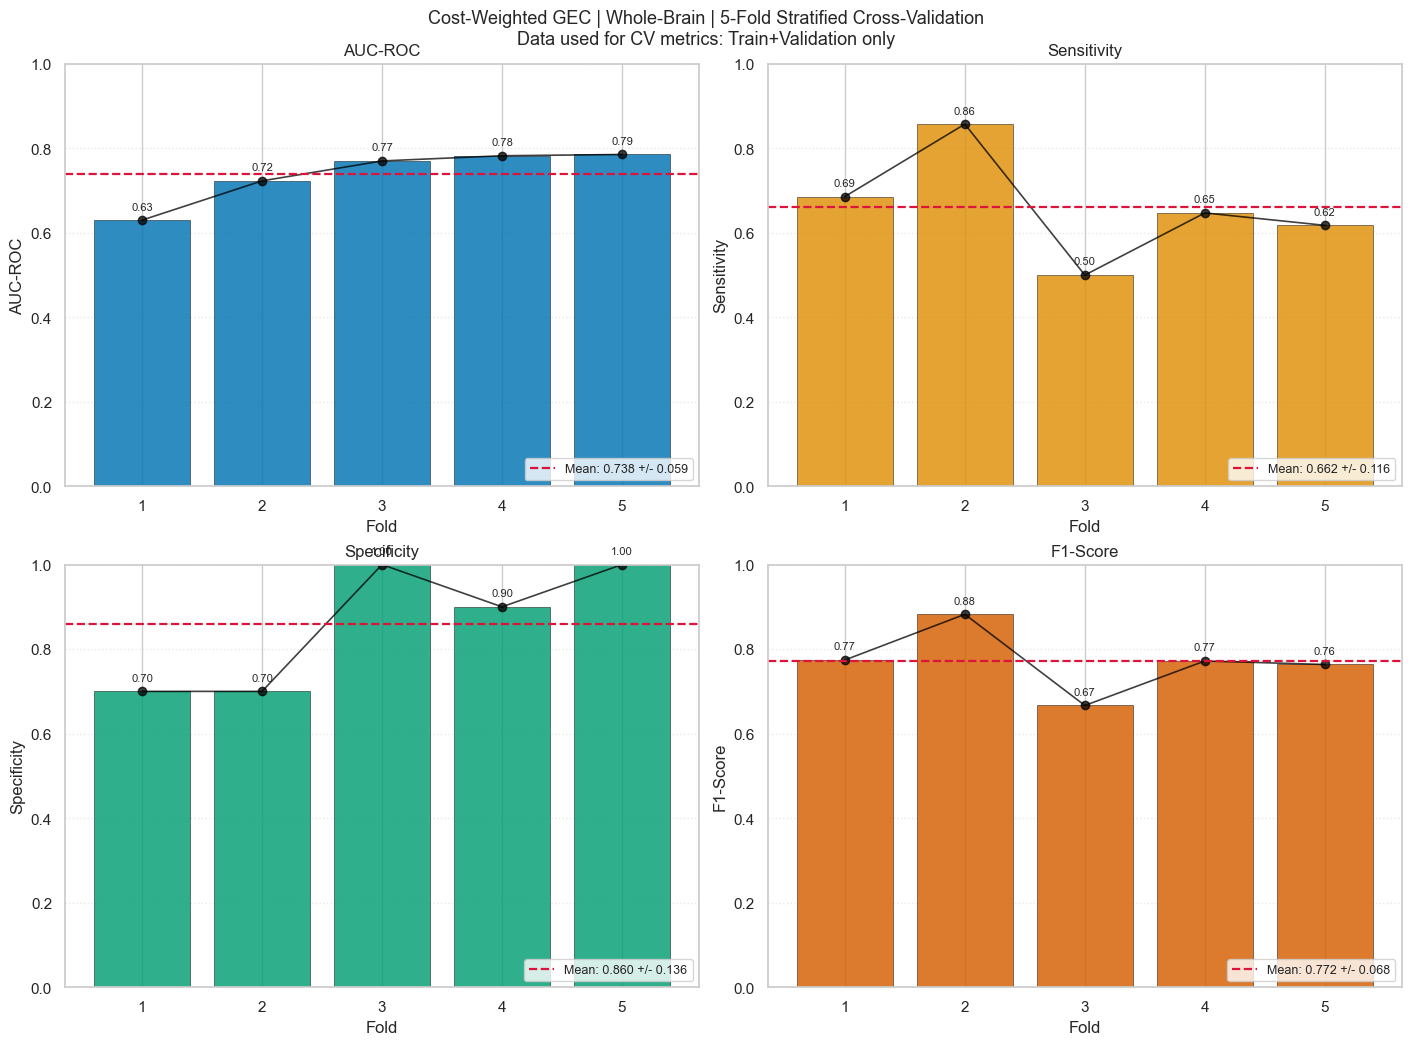

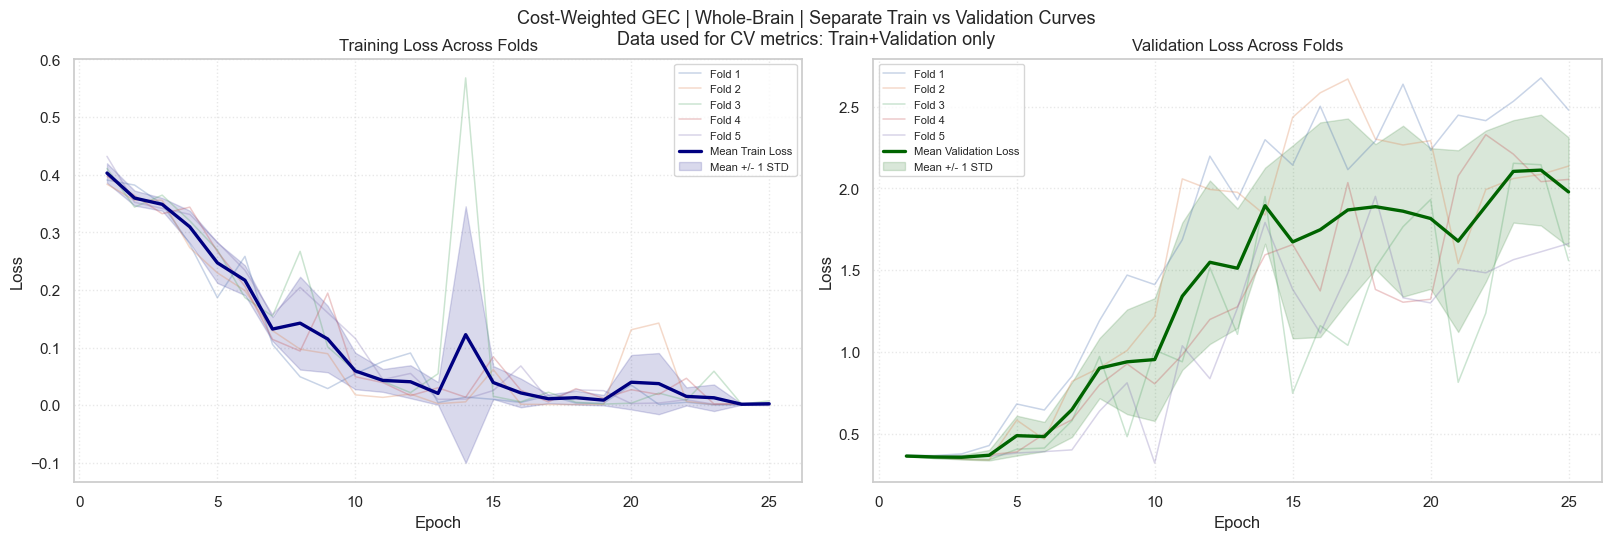

In [16]:
region_label = 'Whole-Brain' if str(CORRELATION_TYPE).lower() == 'whole_brain' else 'DMN-Only'
model_label = 'Cost-Weighted GEC'
data_scope_label = 'Data used for CV metrics: Train+Validation only'

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

metrics = ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']
titles = ['AUC-ROC', 'Sensitivity', 'Specificity', 'F1-Score']
colors = sns.color_palette('colorblind', len(metrics))

for ax, metric, title, color in zip(axes.flat, metrics, titles, colors):
    values = np.array(cv_results[metric], dtype=float)
    fold_x = np.arange(1, len(values) + 1)
    mean_val = float(np.mean(values))
    std_val = float(np.std(values))

    bars = ax.bar(fold_x, values, color=color, alpha=0.82, edgecolor='black', linewidth=0.4)
    ax.plot(fold_x, values, color='black', marker='o', linewidth=1.2, alpha=0.75)
    ax.axhline(y=mean_val, color='crimson', linestyle='--', linewidth=1.6, label=f'Mean: {mean_val:.3f} +/- {std_val:.3f}')
    ax.set_xlabel('Fold')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.set_xticks(fold_x)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', linestyle=':', alpha=0.45)
    ax.legend(loc='lower right', fontsize=9)

    for rect, val in zip(bars, values):
        ax.text(rect.get_x() + rect.get_width() / 2.0, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=8)

fig.suptitle(
    f'{model_label} | {region_label} | 5-Fold Stratified Cross-Validation\n{data_scope_label}',
    fontsize=13,
    y=1.03,
)
plt.show()

train_histories = [np.array(h, dtype=float) for h in cv_histories.get('train_loss', []) if len(h) > 0]
val_histories = [np.array(h, dtype=float) for h in cv_histories.get('val_loss', []) if len(h) > 0]

if train_histories and val_histories:
    max_train_len = max(len(h) for h in train_histories)
    max_val_len = max(len(h) for h in val_histories)

    train_mat = np.full((len(train_histories), max_train_len), np.nan, dtype=float)
    val_mat = np.full((len(val_histories), max_val_len), np.nan, dtype=float)

    for i, h in enumerate(train_histories):
        train_mat[i, :len(h)] = h
    for i, h in enumerate(val_histories):
        val_mat[i, :len(h)] = h

    train_mean = np.nanmean(train_mat, axis=0)
    train_std = np.nanstd(train_mat, axis=0)
    val_mean = np.nanmean(val_mat, axis=0)
    val_std = np.nanstd(val_mat, axis=0)

    epoch_train = np.arange(1, max_train_len + 1)
    epoch_val = np.arange(1, max_val_len + 1)

    fig2, ax2 = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

    for fold_i, h in enumerate(train_histories, start=1):
        ax2[0].plot(np.arange(1, len(h) + 1), h, alpha=0.3, linewidth=1.1, label=f'Fold {fold_i}' if fold_i <= 5 else None)
    ax2[0].plot(epoch_train, train_mean, color='navy', linewidth=2.4, label='Mean Train Loss')
    ax2[0].fill_between(epoch_train, train_mean - train_std, train_mean + train_std, color='navy', alpha=0.15, label='Mean +/- 1 STD')
    ax2[0].set_title('Training Loss Across Folds')
    ax2[0].set_xlabel('Epoch')
    ax2[0].set_ylabel('Loss')
    ax2[0].grid(linestyle=':', alpha=0.45)
    ax2[0].legend(fontsize=8)

    for fold_i, h in enumerate(val_histories, start=1):
        ax2[1].plot(np.arange(1, len(h) + 1), h, alpha=0.3, linewidth=1.1, label=f'Fold {fold_i}' if fold_i <= 5 else None)
    ax2[1].plot(epoch_val, val_mean, color='darkgreen', linewidth=2.4, label='Mean Validation Loss')
    ax2[1].fill_between(epoch_val, val_mean - val_std, val_mean + val_std, color='darkgreen', alpha=0.15, label='Mean +/- 1 STD')
    ax2[1].set_title('Validation Loss Across Folds')
    ax2[1].set_xlabel('Epoch')
    ax2[1].set_ylabel('Loss')
    ax2[1].grid(linestyle=':', alpha=0.45)
    ax2[1].legend(fontsize=8)

    fig2.suptitle(
        f'{model_label} | {region_label} | Separate Train vs Validation Curves\n{data_scope_label}',
        fontsize=13,
        y=1.05,
    )
    plt.show()
else:
    print('No train/validation history found. Run cross-validation cell before plotting loss curves.')

## Save Best Model and Results

In [14]:
if USE_CW_GEC_CHECKPOINT:
    if CW_GEC_SELECTED_RUN_DIR is None:
        raise RuntimeError('Cost-Weighted GEC checkpoint mode is enabled but no checkpoint run directory was selected.')
    run_artifact_dir = str(CW_GEC_SELECTED_RUN_DIR)
    active_run_dir = Path(run_artifact_dir)
    run_name = active_run_dir.name
    print(f'Checkpoint mode active. Reusing existing run directory: {run_artifact_dir}')
else:
    if best_model_state is None:
        raise RuntimeError('No trained Cost-Weighted GEC model state found to save. Run training first.')

    best_threshold_overall = float(np.median(cv_results['best_threshold']))

    run_timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    try:
        wandb_run_name = wandb.run.name if wandb and wandb.run and wandb.run.name else 'cv_run'
    except Exception:
        wandb_run_name = 'cv_run'
    wandb_run_name = str(wandb_run_name).replace(' ', '-')
    run_name = f'{wandb_run_name}_{run_timestamp}'

    run_artifact_dir = os.path.join(CW_GEC_OUTPUT_DIR, run_name)
    os.makedirs(run_artifact_dir, exist_ok=True)
    active_run_dir = Path(run_artifact_dir)

    model_filename = f'best_model_fold{best_fold}.pth'
    model_file = os.path.join(run_artifact_dir, model_filename)
    torch.save(best_model_state, model_file)
    print(f'Saved best model to {model_file}')

    results_file = os.path.join(run_artifact_dir, 'cv_results.json')
    with open(results_file, 'w') as f:
        json.dump(cv_results, f, indent=2)
    print(f'Saved CV results to {results_file}')

    run_summary = {
        'run_name': run_name,
        'timestamp': run_timestamp,
        'n_folds': N_FOLDS,
        'best_fold': int(best_fold),
        'best_val_auc': float(best_val_auc),
        'best_threshold': float(best_threshold_overall),
        'cv_results': cv_results,
        'cv_histories': {
            'train_loss': cv_histories.get('train_loss', []),
            'val_loss': cv_histories.get('val_loss', []),
        },
        'config': {
            'in_features': IN_FEATURES,
            'hidden_dim': HIDDEN_DIM,
            'latent_dim': LATENT_DIM,
            'cond_dim': COND_DIM,
            'num_heads': NUM_HEADS,
            'dropout': DROPOUT,
            'classifier_hidden': CLASSIFIER_HIDDEN,
            'batch_size': BATCH_SIZE,
            'learning_rate': LEARNING_RATE,
            'epochs': EPOCHS,
            'early_stopping_patience': EARLY_STOPPING_PATIENCE,
            'knn_k': KNN_K,
            'file_variant': FILE_VARIANT,
            'correlation_type': CORRELATION_TYPE,
            'freeze_encoder': FREEZE_ENCODER,
            'gaae_checkpoint': GAAE_CHECKPOINT_PATH,
            'wb_root': WB_ROOT,
            'use_scheduler': USE_SCHEDULER,
            'use_class_cost_weights': USE_CLASS_COST_WEIGHTS,
            'normalize_class_cost_weights': NORMALIZE_CLASS_COST_WEIGHTS,
        },
    }
    summary_file = os.path.join(run_artifact_dir, 'run_summary.json')
    with open(summary_file, 'w') as f:
        json.dump(run_summary, f, indent=2)
    print(f'Saved run summary to {summary_file}')
    print(f'Median CV threshold: {best_threshold_overall:.4f}')

print(f'Active artifact directory: {active_run_dir}')

Saved best model to /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_cost_weighted_gec_whole_brain/cv_run_2026-04-21_18-05-41/best_model_fold5.pth
Saved CV results to /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_cost_weighted_gec_whole_brain/cv_run_2026-04-21_18-05-41/cv_results.json
Saved run summary to /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_cost_weighted_gec_whole_brain/cv_run_2026-04-21_18-05-41/run_summary.json
Median CV threshold: 0.9879
Active artifact directory: /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_cost_weighted_gec_whole_brain/cv_run_2026-04-21_18-05-41


## Robustness Evaluation (Threshold from Reconstruction Error)

Using evaluation threshold: 0.987908
Selected Top-5 non-converter correctly predicted samples (validation set):
 DatasetIndex PatientID  Probability   Margin
          551 df57b92f6     0.000197 0.987711
          411 86b7754e0     0.000320 0.987588
          255 23cd008c9     0.000885 0.987023
          508 bd6b65027     0.001199 0.986709
          427 8eef0619f     0.001611 0.986298


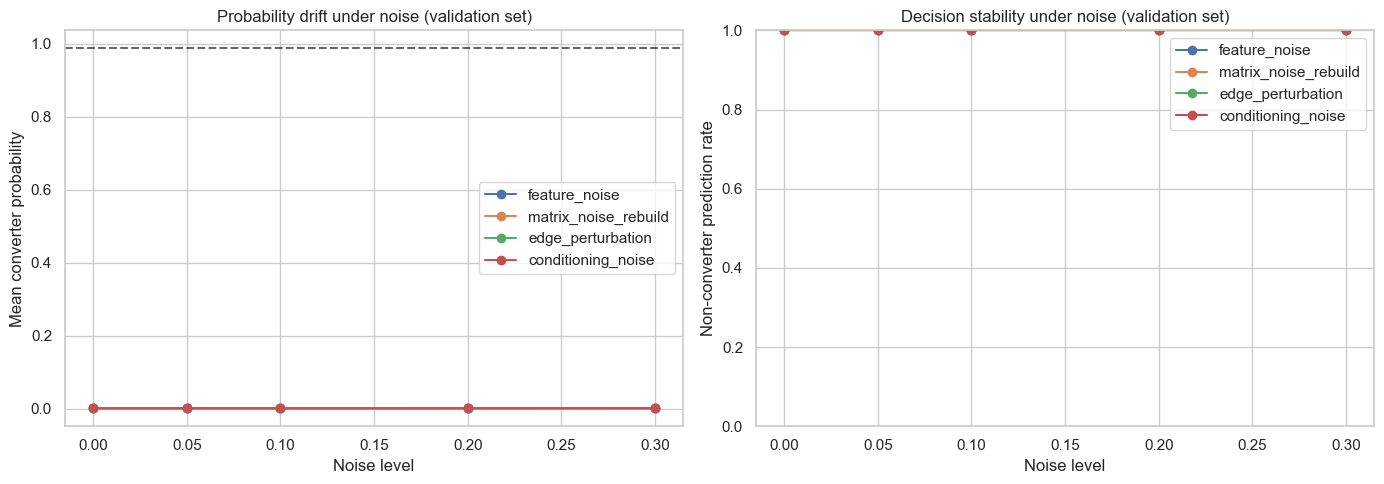

Saved evaluation artifacts to: /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_cost_weighted_gec_whole_brain/cv_run_2026-04-21_18-05-41/robustness_eval_2026-04-21_18-05-47


In [15]:
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

np.random.seed(42)
torch.manual_seed(42)

if 'best_model_state' not in globals() or best_model_state is None:
    raise RuntimeError('best_model_state is missing. Run cross-validation training first.')

if 'GraphEncoderClassifierAttention' not in globals():
    raise RuntimeError('GraphEncoderClassifierAttention is missing. Run imports first.')

if 'val_split_indices' not in globals() or 'all_labels' not in globals() or 'combined_dataset' not in globals():
    raise RuntimeError('Validation data variables are missing. Run split and dataset cells first.')

eval_model = GraphEncoderClassifierAttention(
    in_features=IN_FEATURES,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM,
    cond_dim=COND_DIM,
    num_heads=NUM_HEADS,
    dropout=DROPOUT,
    classifier_hidden=CLASSIFIER_HIDDEN,
).to(device)
eval_model.load_state_dict(best_model_state)
eval_model.eval()

if 'best_threshold_overall' in globals():
    eval_threshold = float(best_threshold_overall)
elif 'CLASSIFICATION_THRESHOLD' in globals():
    eval_threshold = float(CLASSIFICATION_THRESHOLD)
else:
    eval_threshold = 0.5

print(f'Using evaluation threshold: {eval_threshold:.6f}')

def clone_sample(sample):
    cloned = sample.clone()
    if hasattr(cloned, 'x') and torch.is_tensor(cloned.x):
        cloned.x = cloned.x.clone()
    if hasattr(cloned, 'edge_index') and torch.is_tensor(cloned.edge_index):
        cloned.edge_index = cloned.edge_index.clone()
    if hasattr(cloned, 'edge_attr') and torch.is_tensor(cloned.edge_attr):
        cloned.edge_attr = cloned.edge_attr.clone()
    return cloned

def infer_probability(sample, noise_method='none', noise_level=0.0):
    d = clone_sample(sample)
    if noise_method in {'feature_noise', 'matrix_noise_rebuild'} and noise_level > 0:
        base_std = float(d.x.std().item()) if d.x.numel() > 1 else 1.0
        d.x = d.x + torch.randn_like(d.x) * (base_std * noise_level)
    if noise_method == 'matrix_noise_rebuild':
        adj_bin = knn_binary_adjacency_matrix_no_diag(d.x.detach().cpu().numpy(), **adjacency_args)
        src, dst = np.where(adj_bin > 0)
        if len(src) == 0:
            src = np.arange(max(0, d.x.size(0) - 1))
            dst = src + 1
        edge_index = np.vstack([src, dst])
        d.edge_index = torch.tensor(edge_index, dtype=torch.long)
    if noise_method == 'edge_perturbation' and noise_level > 0:
        edge_index = d.edge_index.detach().cpu()
        num_edges = edge_index.size(1)
        keep = max(1, int(round(num_edges * (1.0 - noise_level))))
        keep_perm = torch.randperm(num_edges)[:keep]
        kept_edges = edge_index[:, keep_perm]
        add_count = int(round(num_edges * noise_level))
        n_nodes = d.x.size(0)
        if add_count > 0:
            new_src = torch.randint(0, n_nodes, (add_count,), dtype=torch.long)
            new_dst = torch.randint(0, n_nodes, (add_count,), dtype=torch.long)
            valid = new_src != new_dst
            new_src = new_src[valid]
            new_dst = new_dst[valid]
            if new_src.numel() > 0:
                add_edges = torch.stack([new_src, new_dst], dim=0)
                d.edge_index = torch.cat([kept_edges, add_edges], dim=1)
            else:
                d.edge_index = kept_edges
        else:
            d.edge_index = kept_edges

    age = float(d.patient_age.item()) if torch.is_tensor(d.patient_age) else float(d.patient_age)
    sex = float(d.patient_sex.item()) if torch.is_tensor(d.patient_sex) else float(d.patient_sex)
    if noise_method == 'conditioning_noise' and noise_level > 0:
        age = age + float(np.random.normal(0.0, noise_level * 0.05))
        sex = float(np.clip(sex + np.random.normal(0.0, noise_level * 0.1), 0.0, 1.0))

    d = d.to(device)
    cond_vec = torch.tensor([[age, sex]], dtype=torch.float32, device=device)
    batch_mask = torch.zeros(d.x.size(0), dtype=torch.long, device=device)

    with torch.no_grad():
        logits, _ = eval_model(d.x, d.edge_index, cond_vec, batch_mask)
    prob = float(torch.sigmoid(logits).view(-1)[0].item())
    pred = int(prob >= eval_threshold)
    return prob, pred

non_converter_indices = [idx for idx in val_split_indices if int(all_labels[idx]) == 0]
if len(non_converter_indices) == 0:
    raise RuntimeError('No non-converter samples found in validation set.')

baseline_rows = []
for idx in non_converter_indices:
    sample = combined_dataset[idx]
    prob, pred = infer_probability(sample, noise_method='none', noise_level=0.0)
    if pred == 0:
        patient_id = str(getattr(sample, 'patient_id', f'idx_{idx}'))
        baseline_rows.append(
            {
                'DatasetIndex': int(idx),
                'PatientID': patient_id,
                'Probability': float(prob),
                'Margin': float(eval_threshold - prob),
            }
        )

baseline_df = pd.DataFrame(baseline_rows)
if baseline_df.empty:
    raise RuntimeError('No correctly predicted non-converter samples found at baseline.')

selected_df = baseline_df.sort_values('Margin', ascending=False).head(5)
print('Selected Top-5 non-converter correctly predicted samples (validation set):')
print(selected_df.to_string(index=False))

noise_levels = [0.00, 0.05, 0.10, 0.20, 0.30]
n_trials = 10
noise_methods = ['feature_noise', 'matrix_noise_rebuild', 'edge_perturbation', 'conditioning_noise']

records = []
for _, row in selected_df.iterrows():
    ds_idx = int(row['DatasetIndex'])
    base_sample = combined_dataset[ds_idx]
    patient_id = str(row['PatientID'])
    for method in noise_methods:
        for noise_level in noise_levels:
            for trial in range(n_trials):
                prob, pred = infer_probability(base_sample, noise_method=method, noise_level=float(noise_level))
                pred_non_converter = int(pred == 0)
                records.append(
                    {
                        'PatientID': patient_id,
                        'DatasetIndex': ds_idx,
                        'Method': method,
                        'NoiseLevel': float(noise_level),
                        'Trial': trial,
                        'Probability': float(prob),
                        'PredNonConverter': pred_non_converter,
                    }
                )

robustness_df = pd.DataFrame(records)
summary_df = (
    robustness_df
    .groupby(['Method', 'NoiseLevel'], as_index=False)
    .agg(
        MeanProbability=('Probability', 'mean'),
        StdProbability=('Probability', 'std'),
        NonConverterRate=('PredNonConverter', 'mean')
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for method in noise_methods:
    m = summary_df[summary_df['Method'] == method]
    axes[0].plot(m['NoiseLevel'], m['MeanProbability'], marker='o', label=method)
axes[0].axhline(eval_threshold, linestyle='--', color='black', alpha=0.6)
axes[0].set_xlabel('Noise level')
axes[0].set_ylabel('Mean converter probability')
axes[0].set_title('Probability drift under noise (validation set)')
axes[0].legend()

for method in noise_methods:
    m = summary_df[summary_df['Method'] == method]
    axes[1].plot(m['NoiseLevel'], m['NonConverterRate'], marker='o', label=method)
axes[1].set_xlabel('Noise level')
axes[1].set_ylabel('Non-converter prediction rate')
axes[1].set_ylim(0, 1)
axes[1].set_title('Decision stability under noise (validation set)')
axes[1].legend()

plt.tight_layout()
plt.show()

base_dir = Path(run_artifact_dir) if 'run_artifact_dir' in globals() else Path.cwd()
eval_dir = base_dir / f'robustness_eval_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}'
eval_dir.mkdir(parents=True, exist_ok=True)

selected_file = eval_dir / 'selected_non_converter_top5.csv'
summary_file = eval_dir / 'robustness_summary.csv'
details_file = eval_dir / 'robustness_details.csv'
meta_file = eval_dir / 'robustness_meta.json'

selected_df.to_csv(selected_file, index=False)
summary_df.to_csv(summary_file, index=False)
robustness_df.to_csv(details_file, index=False)

meta = {
    'threshold_type': 'trained_classifier_probability_threshold',
    'threshold': eval_threshold,
    'noise_levels': noise_levels,
    'n_trials': n_trials,
    'methods': noise_methods,
    'selected_count': int(len(selected_df)),
    'source_set': 'validation',
}
with open(meta_file, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Saved evaluation artifacts to: {eval_dir}')